# 📊 Notebook 06: EDA — Telco Customer Churn
## Clasificación Supervisada

**Dataset:** Telco Customer Churn (IBM Sample Data Sets)  
**Objetivo:** Predecir si un cliente abandonará el servicio (`Churn = Yes/No`)  
**Tipo:** Clasificación Binaria

**Columnas del dataset (21):**
- `customerID`: Identificador único
- `gender`: Género (Male/Female)
- `SeniorCitizen`: Es adulto mayor (0/1)
- `Partner`: Tiene pareja (Yes/No)
- `Dependents`: Tiene dependientes (Yes/No)
- `tenure`: Meses como cliente
- `PhoneService`, `MultipleLines`, `InternetService`
- `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`
- `StreamingTV`, `StreamingMovies`
- `Contract`: Tipo de contrato (Month-to-month, One year, Two year)
- `PaperlessBilling`, `PaymentMethod`
- `MonthlyCharges`, `TotalCharges`
- `Churn`: **TARGET** (Yes/No)

In [1]:
# ─────────────────────────────────────────
# IMPORTACIONES
# ─────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
sns.set_palette('husl')

print('✅ Librerías importadas')

✅ Librerías importadas


## 1. Carga del Dataset

In [2]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'📦 Shape: {df.shape}')
print(f'📋 Columnas: {list(df.columns)}')
df.head()

📦 Shape: (7043, 21)
📋 Columnas: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Información General

In [3]:
print('='*60)
print('INFORMACIÓN DEL DATASET')
print('='*60)
df.info()

print('\n📊 Estadísticas Descriptivas (numéricas):')
df.describe().round(2)

INFORMACIÓN DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  

,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


In [4]:
# Tipos de columnas
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()

print(f'📋 Variables categóricas ({len(cat_cols)}): {cat_cols}')
print(f'📊 Variables numéricas  ({len(num_cols)}): {num_cols}')

📋 Variables categóricas (18): ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']
📊 Variables numéricas  (3): ['SeniorCitizen', 'tenure', 'MonthlyCharges']


## 3. Variable Objetivo: Churn

📊 DISTRIBUCIÓN DEL TARGET (Churn):
  No Churn: 5,174 (73.5%)
  Churn:    1,869 (26.5%)

⚠️  Ratio de desbalance: 2.8:1


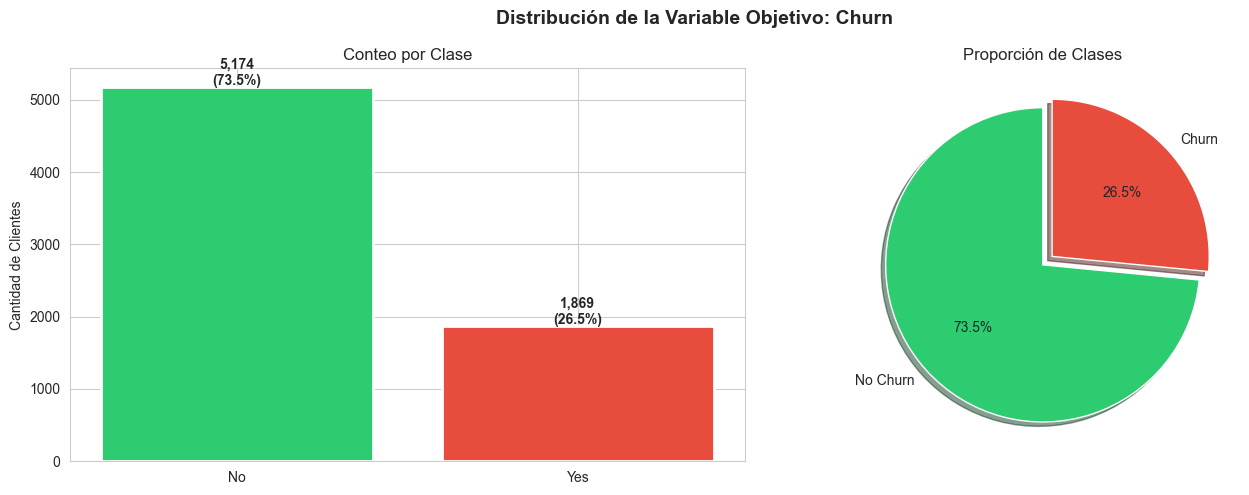


💡 CONCLUSIÓN: Dataset desbalanceado (~73% No Churn vs ~27% Churn)
   → Se requerirá estrategia de manejo de desbalance (class_weight o SMOTE)
   → Accuracy NO es una métrica apropiada. Usar F1, AUC-ROC, Precision-Recall


In [5]:
# ─────────────────────────────────────────
# DESBALANCE DE CLASES — Problema crítico
# ─────────────────────────────────────────
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

print('📊 DISTRIBUCIÓN DEL TARGET (Churn):')
print(f'  No Churn: {churn_counts["No"]:,} ({churn_pct["No"]:.1f}%)')
print(f'  Churn:    {churn_counts["Yes"]:,} ({churn_pct["Yes"]:.1f}%)')
print(f'\n⚠️  Ratio de desbalance: {churn_counts["No"]/churn_counts["Yes"]:.1f}:1')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de la Variable Objetivo: Churn', fontsize=14, fontweight='bold')

# Bar chart
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='white', linewidth=2)
for i, (idx, val) in enumerate(churn_counts.items()):
    axes[0].text(i, val + 30, f'{val:,}\n({churn_pct[idx]:.1f}%)', 
                ha='center', fontweight='bold')
axes[0].set_title('Conteo por Clase')
axes[0].set_ylabel('Cantidad de Clientes')

# Pie chart
axes[1].pie(churn_counts.values, labels=['No Churn', 'Churn'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            explode=(0, 0.08), shadow=True)
axes[1].set_title('Proporción de Clases')

plt.tight_layout()
plt.savefig('../data/processed/churn_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 CONCLUSIÓN: Dataset desbalanceado (~73% No Churn vs ~27% Churn)')
print('   → Se requerirá estrategia de manejo de desbalance (class_weight o SMOTE)')
print('   → Accuracy NO es una métrica apropiada. Usar F1, AUC-ROC, Precision-Recall')

## 4. Análisis de Valores Faltantes

In [6]:
# ─────────────────────────────────────────
# VALORES FALTANTES
# ─────────────────────────────────────────
# TotalCharges puede tener espacios vacíos (no NaN real)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

missing = pd.DataFrame({
    'Faltantes': df.isnull().sum(),
    'Porcentaje_%': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_found = missing[missing['Faltantes'] > 0]

if missing_found.empty:
    print('✅ No hay valores faltantes (NaN)')
else:
    print('⚠️ Valores faltantes encontrados:')
    print(missing_found)

# Verificar TotalCharges nullo vs tenure=0
tc_nulls = df[df['TotalCharges'].isnull()]
print(f'\n📊 TotalCharges nulos: {len(tc_nulls)} registros')
print(f'   ¿Tienen tenure=0? {(tc_nulls["tenure"] == 0).all()}')
print('   → Son clientes nuevos (tenure=0), TotalCharges = 0 lógicamente')

⚠️ Valores faltantes encontrados:
              Faltantes  Porcentaje_%
TotalCharges         11          0.16

📊 TotalCharges nulos: 11 registros
   ¿Tienen tenure=0? True
   → Son clientes nuevos (tenure=0), TotalCharges = 0 lógicamente


## 5. Distribución de Variables Numéricas

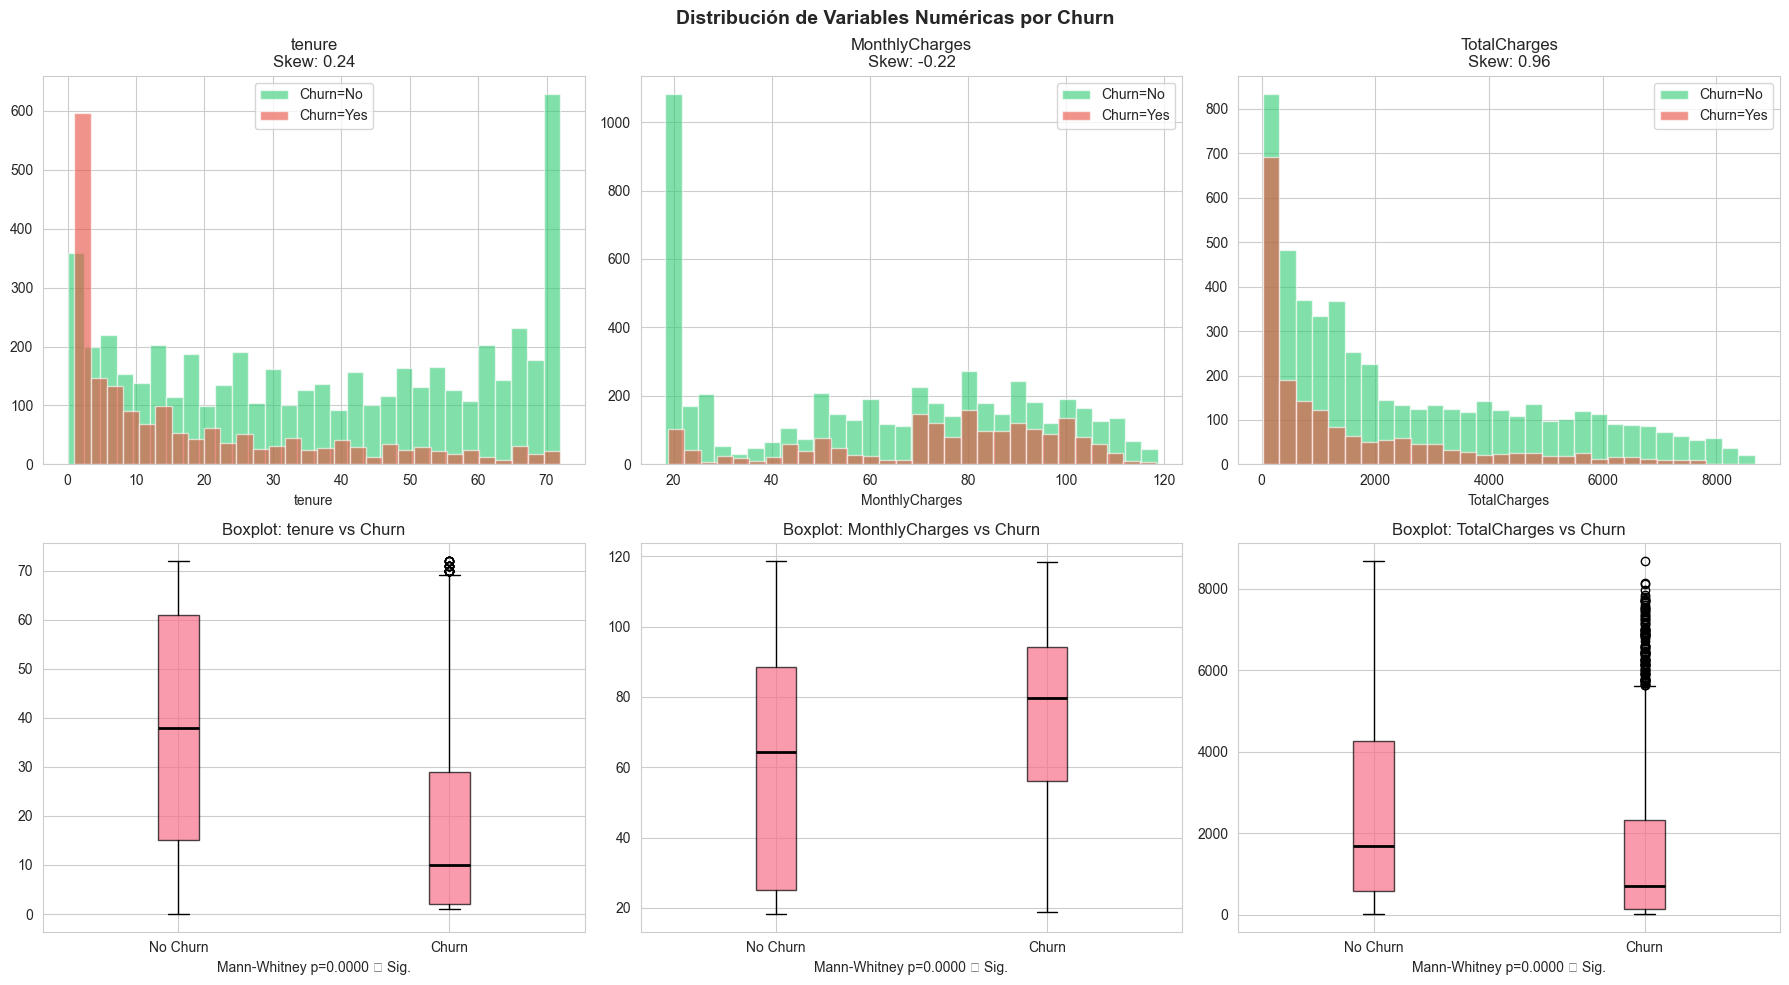

In [7]:
# ─────────────────────────────────────────
# NUMÉRICAS: tenure, MonthlyCharges, TotalCharges
# ─────────────────────────────────────────
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribución de Variables Numéricas por Churn', fontsize=14, fontweight='bold')

for i, col in enumerate(num_features):
    # Histograma por clase
    for j, (churn_val, color) in enumerate([('No', '#2ecc71'), ('Yes', '#e74c3c')]):
        data = df[df['Churn'] == churn_val][col].dropna()
        axes[0, i].hist(data, bins=30, alpha=0.6, color=color, 
                        label=f'Churn={churn_val}', edgecolor='white')
    axes[0, i].set_title(f'{col}\nSkew: {df[col].skew():.2f}')
    axes[0, i].set_xlabel(col)
    axes[0, i].legend()
    
    # Boxplot por clase
    df_plot = df[['Churn', col]].dropna()
    churn_no  = df_plot[df_plot['Churn'] == 'No'][col]
    churn_yes = df_plot[df_plot['Churn'] == 'Yes'][col]
    axes[1, i].boxplot([churn_no, churn_yes],
                       labels=['No Churn', 'Churn'],
                       patch_artist=True,
                       boxprops=dict(alpha=0.7),
                       medianprops=dict(color='black', linewidth=2))
    axes[1, i].set_title(f'Boxplot: {col} vs Churn')
    
    # Mann-Whitney U test
    stat, p = stats.mannwhitneyu(churn_no, churn_yes, alternative='two-sided')
    sig = '✅ Sig.' if p < 0.05 else '❌ No sig.'
    axes[1, i].set_xlabel(f'Mann-Whitney p={p:.4f} {sig}')

plt.tight_layout()
plt.savefig('../data/processed/churn_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Variables Categóricas vs Churn

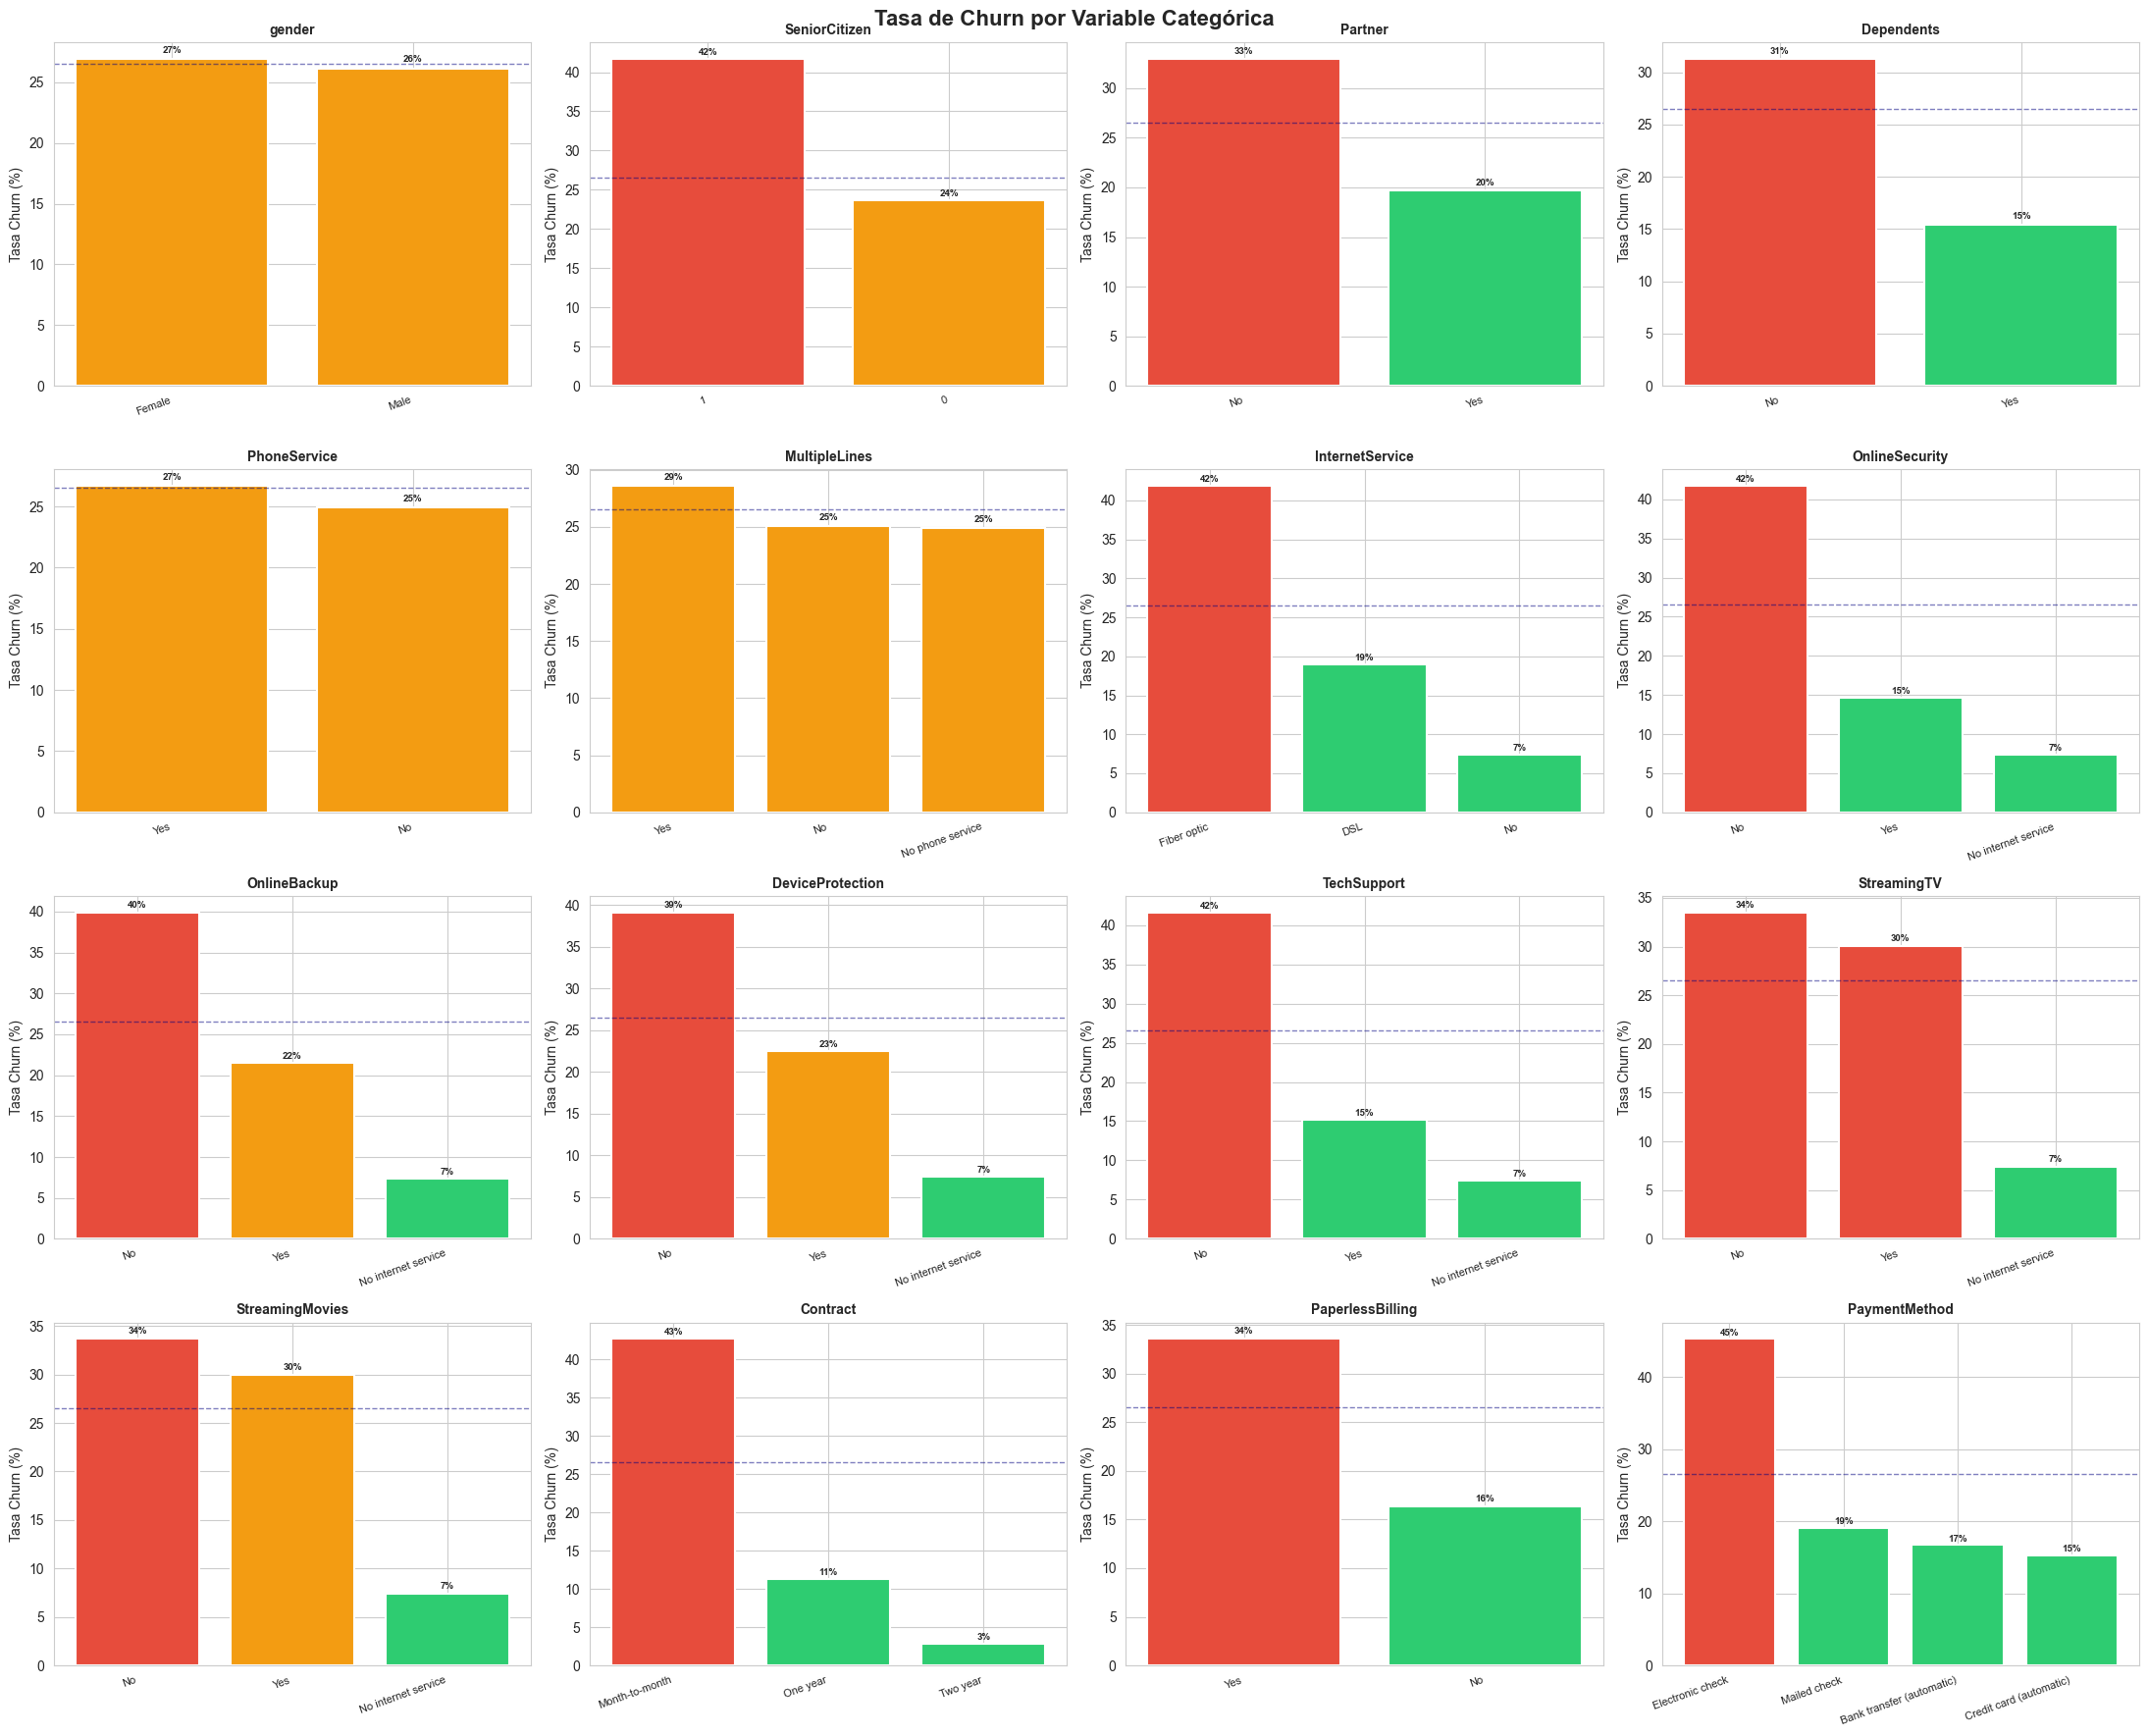

In [8]:
# ─────────────────────────────────────────
# TASA DE CHURN POR CADA VARIABLE CATEGÓRICA
# ─────────────────────────────────────────
cat_features = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

fig, axes = plt.subplots(4, 4, figsize=(22, 18))
fig.suptitle('Tasa de Churn por Variable Categórica', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cat_features):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean() * 100)
    churn_rate = churn_rate.sort_values(ascending=False)
    
    colors = ['#e74c3c' if v > 30 else '#f39c12' if v > 20 else '#2ecc71' 
              for v in churn_rate.values]
    
    bars = axes[i].bar(range(len(churn_rate)), churn_rate.values,
                       color=colors, edgecolor='white', linewidth=1.5)
    axes[i].set_xticks(range(len(churn_rate)))
    axes[i].set_xticklabels(churn_rate.index, rotation=20, ha='right', fontsize=8)
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Tasa Churn (%)')
    axes[i].axhline(y=churn_pct['Yes'], color='navy', linestyle='--', 
                    alpha=0.5, linewidth=1, label=f'Global {churn_pct["Yes"]:.1f}%')
    
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val:.0f}%', ha='center', fontsize=7, fontweight='bold')

# Ocultar ejes sobrantes
for j in range(len(cat_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('../data/processed/churn_categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ─────────────────────────────────────────
# VARIABLES MÁS DISCRIMINATIVAS (Chi-cuadrado)
# ─────────────────────────────────────────
from scipy.stats import chi2_contingency

print('📊 TEST CHI-CUADRADO: Variables Categóricas vs Churn')
print('-'*65)
chi2_results = []
for col in cat_features:
    contingency = pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, _ = chi2_contingency(contingency)
    chi2_results.append({'Variable': col, 'Chi2': chi2, 'p_value': p, 'Significativa': p < 0.05})

chi2_df = pd.DataFrame(chi2_results).sort_values('Chi2', ascending=False)
print(chi2_df.to_string(index=False))

print(f'\n✅ Variables estadísticamente significativas (p<0.05):')
print(chi2_df[chi2_df['Significativa']]['Variable'].tolist())

📊 TEST CHI-CUADRADO: Variables Categóricas vs Churn
-----------------------------------------------------------------
        Variable        Chi2       p_value  Significativa
        Contract 1184.596572 5.863038e-258           True
  OnlineSecurity  849.998968 2.661150e-185           True
     TechSupport  828.197068 1.443084e-180           True
 InternetService  732.309590 9.571788e-160           True
   PaymentMethod  648.142327 3.682355e-140           True
    OnlineBackup  601.812790 2.079759e-131           True
DeviceProtection  558.419369 5.505219e-122           True
 StreamingMovies  375.661479  2.667757e-82           True
     StreamingTV  374.203943  5.528994e-82           True
PaperlessBilling  258.277649  4.073355e-58           True
      Dependents  189.129249  4.924922e-43           True
   SeniorCitizen  159.426300  1.510067e-36           True
         Partner  158.733382  2.139911e-36           True
   MultipleLines   11.330441  3.464383e-03           True
    PhoneSer

## 7. Análisis de Variables Clave

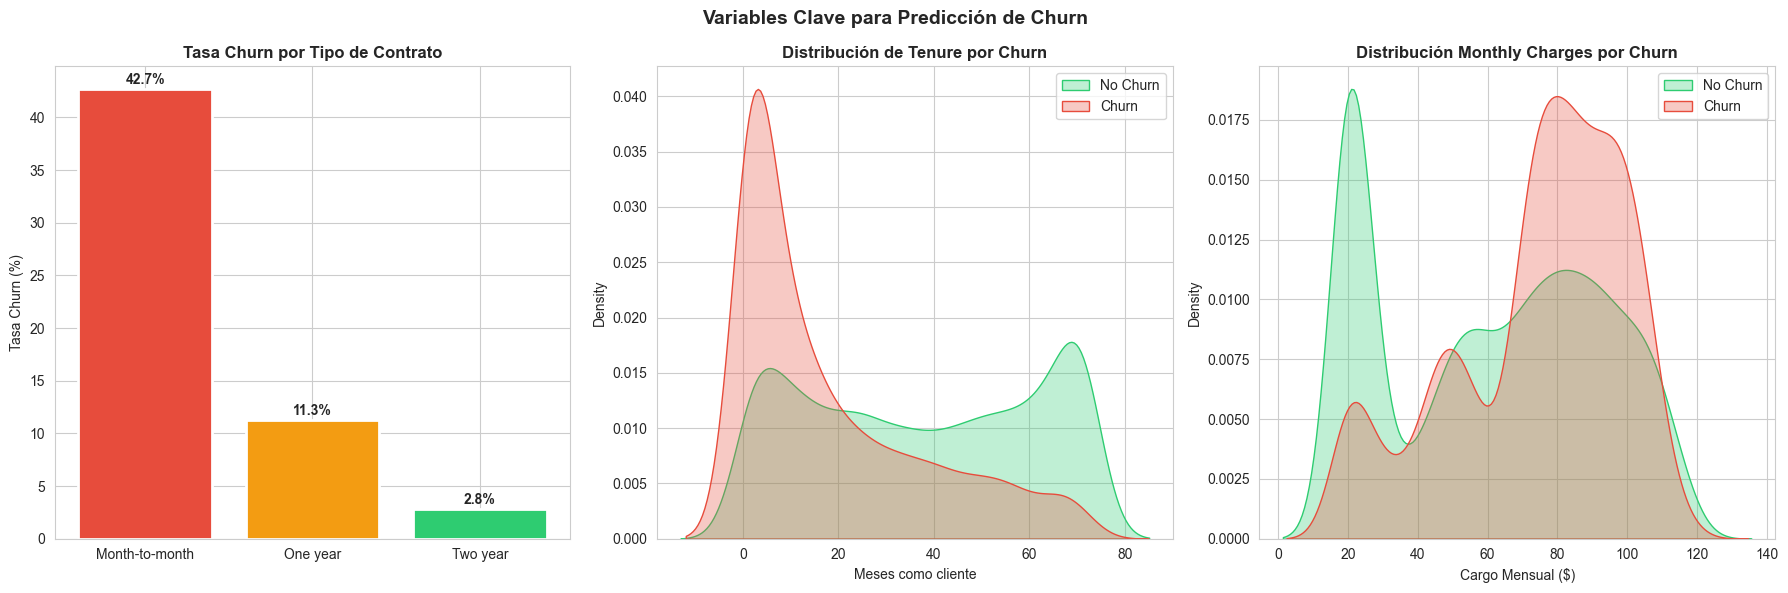

💡 Clientes con contrato Month-to-month tienen ~3x más probabilidad de churn
💡 Clientes con tenure corto y cargos mensuales altos tienen mayor riesgo


In [10]:
# ─────────────────────────────────────────
# ANÁLISIS DETALLADO: Contract, tenure, MonthlyCharges
# ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Variables Clave para Predicción de Churn', fontsize=14, fontweight='bold')

# Contract vs Churn
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean()*100)
axes[0].bar(contract_churn.index, contract_churn.values,
            color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white', linewidth=2)
axes[0].set_title('Tasa Churn por Tipo de Contrato', fontweight='bold')
axes[0].set_ylabel('Tasa Churn (%)')
for i, v in enumerate(contract_churn.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Tenure: distribución
sns.kdeplot(df[df['Churn']=='No']['tenure'], ax=axes[1], color='#2ecc71', 
            label='No Churn', fill=True, alpha=0.3)
sns.kdeplot(df[df['Churn']=='Yes']['tenure'], ax=axes[1], color='#e74c3c', 
            label='Churn', fill=True, alpha=0.3)
axes[1].set_title('Distribución de Tenure por Churn', fontweight='bold')
axes[1].set_xlabel('Meses como cliente')
axes[1].legend()

# MonthlyCharges vs Churn
sns.kdeplot(df[df['Churn']=='No']['MonthlyCharges'], ax=axes[2], color='#2ecc71',
            label='No Churn', fill=True, alpha=0.3)
sns.kdeplot(df[df['Churn']=='Yes']['MonthlyCharges'], ax=axes[2], color='#e74c3c',
            label='Churn', fill=True, alpha=0.3)
axes[2].set_title('Distribución Monthly Charges por Churn', fontweight='bold')
axes[2].set_xlabel('Cargo Mensual ($)')
axes[2].legend()

plt.tight_layout()
plt.savefig('../data/processed/churn_key_features.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 Clientes con contrato Month-to-month tienen ~3x más probabilidad de churn')
print('💡 Clientes con tenure corto y cargos mensuales altos tienen mayor riesgo')

## 8. Matriz de Correlación

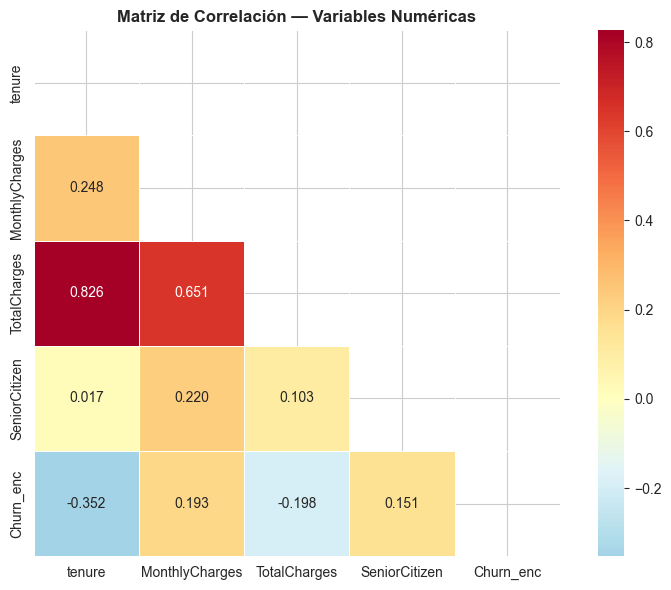

📊 Correlaciones con Churn:
tenure           -0.352229
TotalCharges     -0.198324
MonthlyCharges    0.193356
SeniorCitizen     0.150889
Name: Churn_enc, dtype: float64


In [11]:
# ─────────────────────────────────────────
# CORRELACIÓN (variables numéricas + target encoded)
# ─────────────────────────────────────────
df_corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']].copy()
df_corr['Churn_enc'] = (df['Churn'] == 'Yes').astype(int)
df_corr['TotalCharges'] = df_corr['TotalCharges'].fillna(0)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))
sns.heatmap(df_corr.corr(), annot=True, fmt='.3f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=0.5, ax=ax, mask=mask)
ax.set_title('Matriz de Correlación — Variables Numéricas', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/churn_correlation_matrix.png', dpi=150)
plt.show()

print('📊 Correlaciones con Churn:')
print(df_corr.corr()['Churn_enc'].drop('Churn_enc').sort_values(key=abs, ascending=False))

## 9. Análisis Multivariado

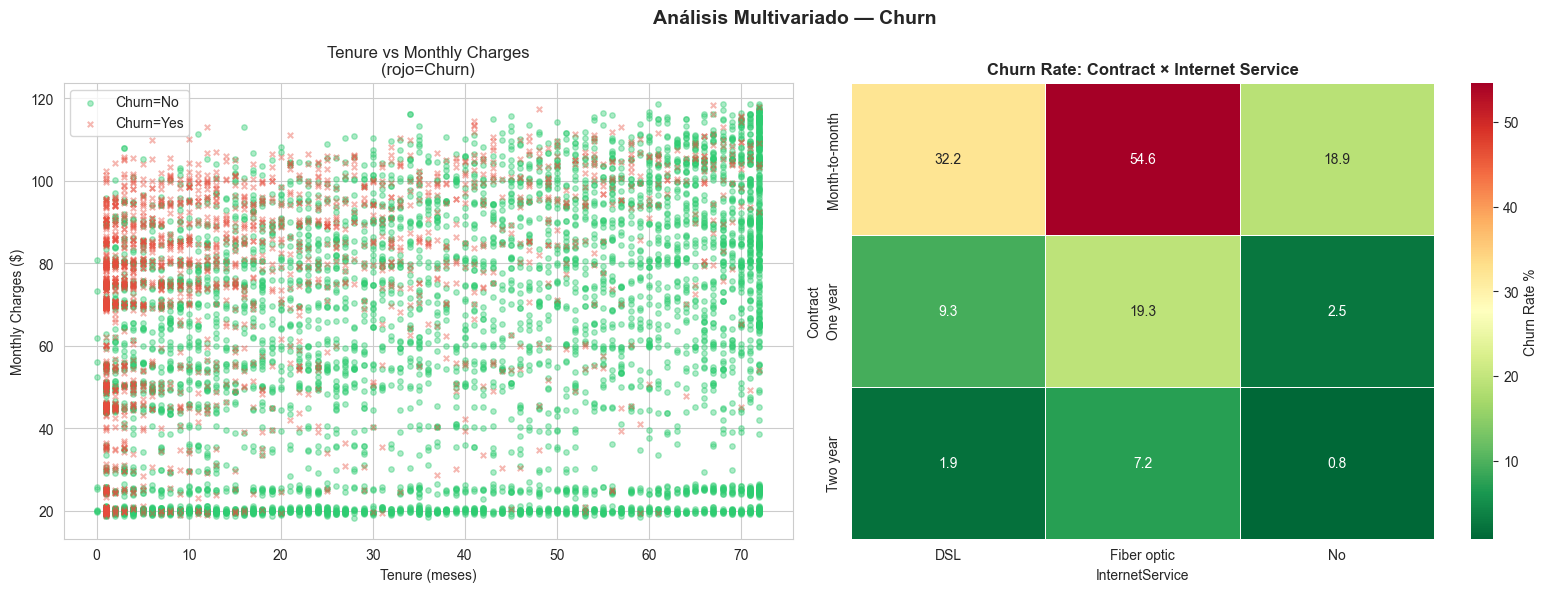

In [12]:
# ─────────────────────────────────────────
# SCATTER: tenure vs MonthlyCharges coloreado por Churn
# ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análisis Multivariado — Churn', fontsize=14, fontweight='bold')

# Scatter tenure vs MonthlyCharges
for churn_val, color, marker in [('No', '#2ecc71', 'o'), ('Yes', '#e74c3c', 'x')]:
    mask = df['Churn'] == churn_val
    axes[0].scatter(df[mask]['tenure'], df[mask]['MonthlyCharges'],
                    c=color, alpha=0.4, s=15, marker=marker, label=f'Churn={churn_val}')
axes[0].set_xlabel('Tenure (meses)')
axes[0].set_ylabel('Monthly Charges ($)')
axes[0].set_title('Tenure vs Monthly Charges\n(rojo=Churn)')
axes[0].legend()

# Heatmap: Contract x InternetService vs Churn Rate
pivot = df.pivot_table(values='Churn', index='Contract', 
                       columns='InternetService',
                       aggfunc=lambda x: (x=='Yes').mean()*100)
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[1], linewidths=0.5, cbar_kws={'label': 'Churn Rate %'})
axes[1].set_title('Churn Rate: Contract × Internet Service', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/churn_multivariate.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. 📝 Conclusiones del EDA

### Hallazgos Clave:

1. **Desbalance de Clases:** ~73% No Churn vs ~27% Churn → Requiere `class_weight='balanced'` o SMOTE

2. **Variables más predictivas:**
   - `Contract`: Los contratos Month-to-month tienen ~42% de churn (vs ~11% anual)
   - `tenure`: Clientes nuevos (< 12 meses) son mucho más propensos a irse
   - `InternetService = Fiber optic`: Tasa de churn alta (~41%)
   - `TechSupport = No`: Sin soporte técnico → mayor churn
   - `OnlineSecurity = No`: Sin seguridad online → mayor churn

3. **Variables menos relevantes:** `gender` (casi igual entre ambas clases)

4. **TotalCharges:** Tiene 11 valores faltantes (clientes con tenure=0), imputar con 0

5. **Alta colinealidad:** tenure ↔ TotalCharges (r=0.83) → considerar al seleccionar features

6. **Perfil de riesgo alto:** Cliente con contrato mensual + Fiber optic + sin seguridad + tenure < 6 meses

### Métricas a usar:
- F1-Score (foco en clase positiva: Churn=Yes)
- AUC-ROC (robustez ante desbalance)
- Precision-Recall AUC
- **NO** usar Accuracy como métrica principal